<a href="https://colab.research.google.com/github/FelipeCostadeSouza/AED_II/blob/main/Algoritmos_base_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install basedosdados

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 kB 10.9 MB/s eta 0:00:00


In [ ]:
import basedosdados as bd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from google.colab import files

billing_id = "banco-dados-508022"


query = """
SELECT
    diretorio_id_municipio.nome AS id_municipio_nome,
    dados.bioma AS bioma,
    MAX(dados.area_total) AS area_total,
    SUM(dados.desmatado) AS desmatado_total
FROM `basedosdados.br_inpe_prodes.municipio_bioma` AS dados
LEFT JOIN (
    SELECT DISTINCT id_municipio, nome
    FROM `basedosdados.br_bd_diretorios_brasil.municipio`
) AS diretorio_id_municipio
    ON dados.id_municipio = diretorio_id_municipio.id_municipio
    WHERE dados.ano = 2022
GROUP BY
    dados.id_municipio,
    diretorio_id_municipio.nome,
    dados.bioma
"""


df = bd.read_sql(query=query, billing_project_id=billing_id)


df.to_csv('dados_prodes_municipios.csv', index=False, encoding='utf-8-sig')
files.download('dados_prodes_municipios.csv')


df.head()

Downloading: 100%|██████████|


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,id_municipio_nome,bioma,area_total,desmatado_total
0,Cáceres,Pantanal,17422.29079,3550.1
1,Sonora,Pantanal,711.73186,542.5
2,Rondonópolis,Pantanal,18.05786,5.9
3,Coxim,Pantanal,2020.97092,1079.0
4,Porto Murtinho,Pantanal,10366.10114,3740.5


In [ ]:
import csv
from dataclasses import dataclass
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


@dataclass
class RegistroDesmatamento:
  municipio: str
  bioma: str
  area_total: float
  desmatado_total: float



lista_registros = []


nome_arquivo = "dados_prodes_municipios.csv"

with open(nome_arquivo, mode="r", encoding="utf-8-sig") as arquivo:
  leitor_csv = csv.DictReader(arquivo)

  for linha in leitor_csv:

    area_tot = (
        float(linha["area_total"]) if linha.get("area_total") else 0.0
    )
    desmat_tot = (
        float(linha["desmatado_total"]) if linha.get("desmatado_total") else 0.0
    )


    registro = RegistroDesmatamento(
        municipio=linha.get(
            "id_municipio_nome", ""
        ),
        bioma=linha.get("bioma", ""),
        area_total=area_tot,
        desmatado_total=desmat_tot,
    )


    lista_registros.append(registro)

df = pd.DataFrame([vars(r) for r in lista_registros])

df = df[df["bioma"].str.strip() != ""]

print(f"Total de registros carregados: {len(lista_registros)}\n")


Total de registros carregados: 6536



In [ ]:
def counting_sort(lista, key_func):
    if not lista:
        return []

    chaves = [key_func(x) for x in lista]
    chaves_unicas = sorted(list(set(chaves)))

    chave_para_rank = {valor: i for i, valor in enumerate(chaves_unicas)}
    ranks = [chave_para_rank[k] for k in chaves]

    max_rank = len(chaves_unicas) - 1
    count = [0] * (max_rank + 1)
    output = [None] * len(lista)

    for r in ranks:
        count[r] += 1

    for i in range(1, len(count)):
        count[i] += count[i - 1]

    for registro in reversed(lista):
        r = chave_para_rank[key_func(registro)]
        output[count[r] - 1] = registro
        count[r] -= 1

    return output

def counting_sort2(dados):
  res = counting_sort(dados, lambda r: r.bioma)
  res = counting_sort(res, lambda r: r.municipio)
  res = counting_sort(res, lambda r: r.desmatado_total)
  res  = counting_sort(res, lambda r: r.area_total)
  return res


In [ ]:
def insertion_sort(arr, left=0, right=None, key=lambda x: x):
    if right is None:
        right = len(arr) - 1

    for i in range(left + 1, right + 1):
        key_item = arr[i]
        val_item = key(key_item)
        j = i - 1


        while j >= left and key(arr[j]) > val_item:
            arr[j + 1] = arr[j]
            j -= 1

        arr[j + 1] = key_item

    return arr


def merge(left, right, key=lambda x: x):

    merged = []
    i = j = 0

    while i < len(left) and j < len(right):

        if key(left[i]) <= key(right[j]):
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1

    merged.extend(left[i:])
    merged.extend(right[j:])
    return merged


def timsort(arr, key=lambda x: x):
    min_run = 32
    n = len(arr)


    for i in range(0, n, min_run):
        insertion_sort(arr, i, min(i + min_run - 1, n - 1), key=key)


    size = min_run
    while size < n:
        for start in range(0, n, size * 2):
            midpoint = min(start + size, n)
            end = min(start + size * 2, n)

            if midpoint < end:
                merged_array = merge(
                    arr[start:midpoint], arr[midpoint:end], key=key
                )
                arr[start:end] = merged_array

        size *= 2

    return arr

In [ ]:
import copy
import time

NUM_EXECUCOES = 10

tempos_counting = []
tempos_timsort = []

for _ in range(NUM_EXECUCOES):

    dados_counting = copy.copy(lista_registros)
    dados_timsort = copy.copy(lista_registros)


    t0 = time.perf_counter()
    resultado_counting = counting_sort2(dados_counting)
    t1 = time.perf_counter()
    tempos_counting.append(t1 - t0)


    t0 = time.perf_counter()
    timsort(dados_timsort, key=lambda r: r.bioma)
    timsort(dados_timsort, key=lambda r: r.municipio)
    timsort(dados_timsort, key=lambda r: r.desmatado_total)
    timsort(dados_timsort, key=lambda r: r.area_total)
    t1 = time.perf_counter()
    tempos_timsort.append(t1 - t0)


media_counting = sum(tempos_counting) / NUM_EXECUCOES
media_timsort = sum(tempos_timsort) / NUM_EXECUCOES


print("-" * 60)
print(f"{'Método de Ordenação':<25} | {'Tempo Médio (10 exec.)':<25}")
print("-" * 60)
print(f"{'Counting Sort':<25} | {media_counting:.6f} segundos")
print(f"{'Timsort':<25} | {media_timsort:.6f} segundos")
print("-" * 60)

------------------------------------------------------------
Método de Ordenação       | Tempo Médio (10 exec.)   
------------------------------------------------------------
Counting Sort             | 0.026540 segundos
Timsort                   | 0.095094 segundos
------------------------------------------------------------


In [ ]:

lista_registros.sort(key=lambda r: r.bioma)
lista_registros.sort(key=lambda r: r.municipio)
lista_registros.sort(key=lambda r: r.area_total)
lista_registros.sort(key=lambda r: r.desmatado_total)

for r in lista_registros[:50]:
    print(
      f"Município: {r.municipio} | Bioma: {r.bioma} | Área Total:"
      f" {r.area_total} km² | Desmatado: {r.desmatado_total} km²"
    )

print("----------------------")

for r in lista_registros[-50:]:
    print(
      f"Município: {r.municipio} | Bioma: {r.bioma} | Área Total:"
      f" {r.area_total} km² | Desmatado: {r.desmatado_total} km²"
    )



Município: Getúlio Vargas | Bioma: Pampa | Área Total: 0.0 km² | Desmatado: 0.0 km²
Município: Santa Clara d'Oeste | Bioma: Cerrado | Área Total: 0.0 km² | Desmatado: 0.0 km²
Município: Douradina | Bioma: Cerrado | Área Total: 0.00014 km² | Desmatado: 0.0 km²
Município: Taquaral | Bioma: Mata Atlântica | Área Total: 0.00021 km² | Desmatado: 0.0 km²
Município: Sátiro Dias | Bioma: Mata Atlântica | Área Total: 0.00031 km² | Desmatado: 0.0 km²
Município: Araioses | Bioma: Caatinga | Área Total: 0.00047 km² | Desmatado: 0.0 km²
Município: Cerro Branco | Bioma: Pampa | Área Total: 0.00047 km² | Desmatado: 0.0 km²
Município: Veredinha | Bioma: Mata Atlântica | Área Total: 0.00301 km² | Desmatado: 0.0 km²
Município: Ponte Preta | Bioma: Pampa | Área Total: 0.00851 km² | Desmatado: 0.0 km²
Município: Esmeraldas | Bioma: Mata Atlântica | Área Total: 0.00883 km² | Desmatado: 0.0 km²
Município: Brasília | Bioma: Mata Atlântica | Área Total: 0.01226 km² | Desmatado: 0.0 km²
Município: Feira da Mat

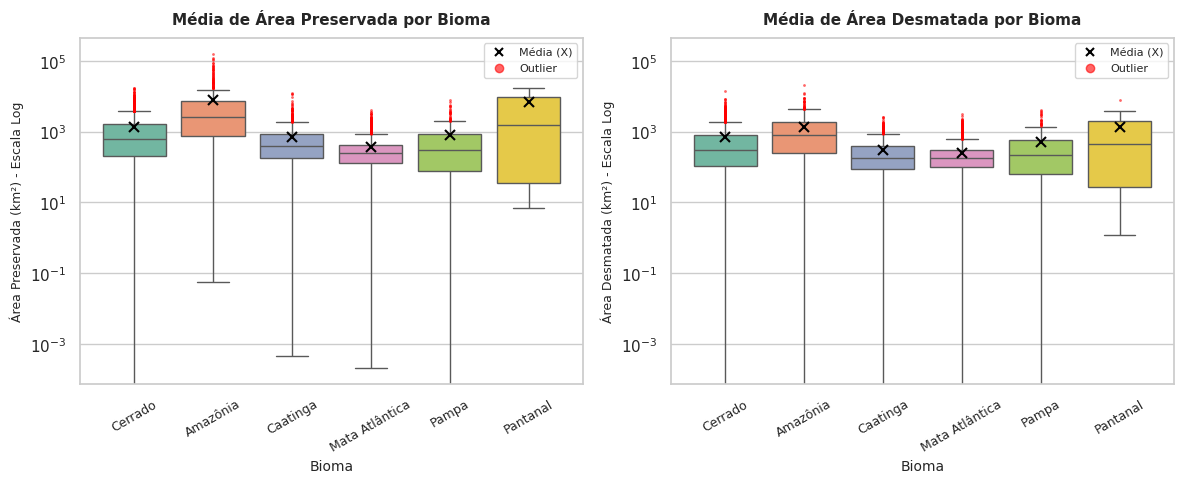

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


sns.set_theme(style="whitegrid")

flierprops = dict(
    marker="o",
    markerfacecolor="red",
    markersize=2,
    linestyle="none",
    markeredgecolor="none",
    alpha=0.6,
)

meanprops = {
    "marker": "x",
    "markerfacecolor": "black",
    "markeredgecolor": "black",
    "markersize": "7",
    "markeredgewidth": "1.5",
}


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


df_agrupado_area = (
    df.groupby(["municipio", "bioma"], as_index=False)["area_total"].mean()
)

sns.boxplot(
    data=df_agrupado_area,
    x="bioma",
    y="area_total",
    palette="Set2",
    width=0.8,
    showmeans=True,
    meanprops=meanprops,
    flierprops=flierprops,
    ax=ax1,
)

ax1.set_title(
    "Média de Área Preservada por Bioma",
    fontsize=11,
    pad=10,
    fontweight="bold",
)
ax1.set_xlabel("Bioma", fontsize=10)
ax1.set_ylabel("Área Preservada (km²) - Escala Log", fontsize=9)
ax1.set_yscale("log")
ax1.tick_params(axis="x", rotation=30, labelsize=9)

ax1.plot(
    [],
    [],
    marker="x",
    color="black",
    linestyle="None",
    markeredgewidth=1.5,
    label="Média (X)",
)
ax1.plot(
    [],
    [],
    marker="o",
    color="red",
    linestyle="None",
    alpha=0.6,
    label="Outlier",
)
ax1.legend(loc="upper right", fontsize=8)

limites_y = ax1.get_ylim()

df_agrupado_desmat = (
    df.groupby(["municipio", "bioma"], as_index=False)["desmatado_total"].mean()
)

sns.boxplot(
    data=df_agrupado_desmat,
    x="bioma",
    y="desmatado_total",
    palette="Set2",
    width=0.8,
    showmeans=True,
    meanprops=meanprops,
    flierprops=flierprops,
    ax=ax2,
)
ax2.set_xlabel("Bioma", fontsize=10)
ax2.set_ylabel("Área Desmatada (km²) - Escala Log", fontsize=9)
ax2.set_yscale("log")
ax2.tick_params(axis="x", rotation=30, labelsize=9)

ax2.set_title(
    "Média de Área Desmatada por Bioma",
    fontsize=11,
    pad=10,
    fontweight="bold",
)

ax2.plot(
    [],
    [],
    marker="x",
    color="black",
    linestyle="None",
    markeredgewidth=1.5,
    label="Média (X)",
)
ax2.plot(
    [],
    [],
    marker="o",
    color="red",
    linestyle="None",
    alpha=0.6,
    label="Outlier",
)
ax2.legend(loc="upper right", fontsize=8)
ax2.set_ylim(limites_y)

plt.tight_layout()
plt.show()

Os biomas Cerrado e Amazônia possuem a maior área desmatada dentre os biomas.  
O município com a maior área desmatada é São Félix do Xingu com aproximadamente 20984km^2 de desmatamento e apenas 84191km^2 de área total.  
Há diversos municípios sem nenhum desmatamento registrado.  
Altamira é o município com maior area total preservada, mas possui uma area desmatada ainda maior.  
Getúlio Vargas e Santa Clara d'Oeste possuem 0km^2 de área desmatada e área total, o que é peculiar, pois todo o território é coberto por biomas ou intersecções entre eles, portanto esses municípios devem ser inteiramente cidade em todo o seu território.